In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2, ResNet50, EfficientNetB0
import gc

print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [4]:
X_train = X_train[:10000]
y_train = y_train[:10000]

X_test = X_test[:2000]
y_test = y_test[:2000]

In [5]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (10000, 32, 32, 3)
Testing Shape: (2000, 32, 32, 3)


In [6]:
# =====================================================
# CREATE DATASET PIPELINE
# =====================================================

IMG_SIZE = 96
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

results = {}

In [7]:
# CUSTOM CNN
# =====================================================

print("\nTraining CNN...")

cnn = models.Sequential([
    layers.Input(shape=(96,96,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

   layers.Flatten(),
   layers.Dense(128, activation='relu'),
   layers.Dropout(0.3),

   layers.Dense(10, activation='softmax')
])

cnn.compile(
 optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

cnn.fit(
train_ds,
epochs=5,
validation_data=test_ds,
verbose=1
)

loss, acc = cnn.evaluate(test_ds, verbose=0)
results["CNN"] = acc * 100

tf.keras.backend.clear_session()
gc.collect()


Training CNN...
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.3046 - loss: 1.8923 - val_accuracy: 0.4280 - val_loss: 1.5870
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.4316 - loss: 1.5680 - val_accuracy: 0.4975 - val_loss: 1.3994
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4952 - loss: 1.3794 - val_accuracy: 0.5300 - val_loss: 1.3345
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5561 - loss: 1.2537 - val_accuracy: 0.5485 - val_loss: 1.2498
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.6031 - loss: 1.1131 - val_accuracy: 0.5495 - val_loss: 1.2376


0

In [9]:
# FUNCTION FOR TRANSFER LEARNING MODELS
# =====================================================

def train_pretrained(base_model_fn, model_name):

  print(f"\nTraining {model_name}...")

  base_model = base_model_fn(
    weights='imagenet',
    include_top=False,
    input_shape=(96,96,3)
  )

  base_model.trainable = False

  model = models.Sequential([
     base_model,
     layers.GlobalAveragePooling2D(),
     layers.Dense(128, activation='relu'),
     layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
  ])

  model.compile(
      optimizer='adam',
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
   )

  model.fit(
      train_ds,
      epochs=3,
      validation_data=test_ds,
      verbose=1
   )

  loss, acc = model.evaluate(test_ds, verbose=0)

  results[model_name] = acc * 100

  tf.keras.backend.clear_session()
  gc.collect()

In [10]:
# MOBILE NET V2
# =====================================================

train_pretrained(
   MobileNetV2,
  "MobileNetV2"
)


Training MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 97ms/step - accuracy: 0.6460 - loss: 1.0507 - val_accuracy: 0.7595 - val_loss: 0.7099
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7477 - loss: 0.7214 - val_accuracy: 0.7645 - val_loss: 0.6708
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7768 - loss: 0.6318 - val_accuracy: 0.7745 - val_loss: 0.6303


In [11]:
# =====================================================
# RESNET50
# =====================================================

train_pretrained(
ResNet50,
"ResNet50"
)


Training ResNet50...
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 93ms/step - accuracy: 0.1305 - loss: 2.2933 - val_accuracy: 0.1670 - val_loss: 2.2456
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.1784 - loss: 2.2085 - val_accuracy: 0.2025 - val_loss: 2.1496
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.2103 - loss: 2.1241 - val_accuracy: 0.2255 - val_loss: 2.0760


In [12]:
# EFFICIENTNET B0
# =====================================================

train_pretrained(
    EfficientNetB0,
    "EfficientNetB0"
)


Training EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 64s 115ms/step - accuracy: 0.1007 - loss: 2.3088 - val_accuracy: 0.1085 - val_loss: 2.3024
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.0995 - loss: 2.3025 - val_accuracy: 0.1085 - val_loss: 2.3022
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.1005 - loss: 2.3024 - val_accuracy: 0.0975 - val_loss: 2.3022


In [13]:
# RESULTS
# =====================================================

print("\n============================")
print("MODEL ACCURACY COMPARISON")
print("============================")

for model, accuracy in results.items():
    print(f"{model:15s} : {accuracy:.2f}%")


MODEL ACCURACY COMPARISON
CNN             : 54.95%
MobileNetV2     : 77.45%
ResNet50        : 22.55%
EfficientNetB0  : 9.75%


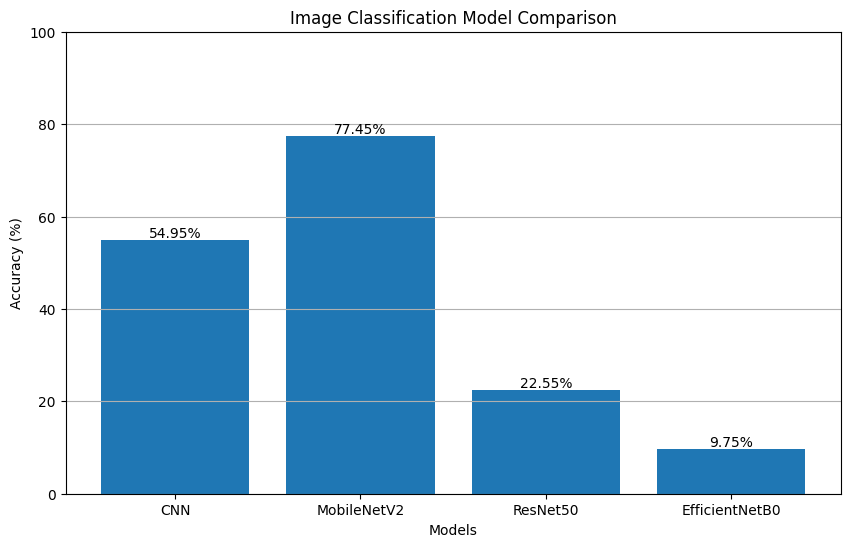

In [14]:
# BAR GRAPH
# =====================================================

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,6))

bars = plt.bar(model_names, accuracies)

plt.title("Image Classification Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for bar in bars:
    y = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
         y + 0.5,
         f"{y:.2f}%",
         ha='center'
   )

plt.ylim(0,100)
plt.grid(axis='y')

plt.show()

In [15]:
# BEST MODEL
# =====================================================

best_model = max(results, key=results.get)

print("\nBest Model:", best_model)
print("Best Accuracy:", round(results[best_model],2), "%")


Best Model: MobileNetV2
Best Accuracy: 77.45 %
